## 🏦 Bank Loan Analysis Report

**Objective:** Analyze a portfolio of consumer loans to understand overall lending performance, identify the drivers of loan defaults ("bad loans"), and surface trends across time, geography, and borrower segments.

**Dataset:** `financial_loan.xlsx` — 38,576 loan records issued in 2021, with fields covering the borrower (state, employment length, home ownership), the loan (amount, term, purpose, grade, interest rate), and the outcome (status, total payment received).

**Key questions this notebook answers:**
- How much has been funded, and how much has actually been collected?
- What share of the portfolio is "good" (Current/Fully Paid) vs. "bad" (Charged Off)?
- Which states, loan purposes, terms, and grades carry the highest default risk?
- How does lending volume trend month over month?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel("financial_loan.xlsx")

In [ ]:
df.head()

In [4]:
print("no of rows:", df.shape[0])

no of rows: 38576


In [5]:
print("no of columns:", df.shape[1])

no of columns: 24


### Data Types

In [6]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [7]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Data Quality Check

Before trusting any KPI below, check for missing values, duplicate records, and out-of-range values in the key numeric fields.

In [8]:
missing = df.isnull().sum()
print("Missing values by column:")
print(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nInterest rate range: {:.2%} to {:.2%}".format(df["int_rate"].min(), df["int_rate"].max()))
print("DTI range: {:.2%} to {:.2%}".format(df["dti"].min(), df["dti"].max()))
print("Issue date range: {} to {}".format(df["issue_date"].min().date(), df["issue_date"].max().date()))

Missing values by column:
emp_title    1438
dtype: int64

Duplicate rows: 0

Interest rate range: 5.42% to 24.59%
DTI range: 0.00% to 29.99%
Issue date range: 2021-01-01 to 2021-12-12


### Total Loan Applications

In [9]:
total_loan_applications = df["id"].count()
print("Total Loan Applications:", total_loan_applications)

Total Loan Applications: 38576


### Prepare Month-to-Date (MTD) Data

The dataset's most recent month is used as the "current" reporting period. This is computed once and reused for every MTD metric below, instead of re-filtering the data each time.

In [10]:
def get_mtd_data(df, date_col="issue_date"):
    """Return the subset of rows from the most recent month present in the data."""
    latest_date = df[date_col].max()
    mask = (df[date_col].dt.year == latest_date.year) & (df[date_col].dt.month == latest_date.month)
    return df[mask], latest_date

mtd_data, latest_issue_date = get_mtd_data(df)
print("MTD reporting period:", latest_issue_date.strftime("%B %Y"))

MTD reporting period: December 2021


### Month to Date Total Loan Applications

In [11]:
mtd_total_applications = mtd_data["id"].count()
print("MTD Loan Applications for {}: {}".format(latest_issue_date.strftime("%B %Y"), mtd_total_applications))

MTD Loan Applications for December 2021: 4314


### Total Funded Amount

In [12]:
total_funded_amount = df["loan_amount"].sum()
total_funded_amount_millions = total_funded_amount / 1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD - Total Funded Amount

In [13]:
mtd_total_funded_amount = mtd_data["loan_amount"].sum()
mtd_total_funded_amount_million = mtd_total_funded_amount / 1000000
print("MTD Total Funded Amount for {}: ${:.2f}M".format(latest_issue_date.strftime("%B %Y"), mtd_total_funded_amount_million))

MTD Total Funded Amount for December 2021: $53.98M


### Total Amount Received

In [14]:
total_amount_received = df["total_payment"].sum()
total_amount_received_millions = total_amount_received / 1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $473.07M


### MTD - Total Amount Received

In [15]:
mtd_total_amount_received = mtd_data["total_payment"].sum()
mtd_total_amount_received_millions = mtd_total_amount_received / 1000000
print("MTD Total Amount Received for {}: ${:.2f}M".format(latest_issue_date.strftime("%B %Y"), mtd_total_amount_received_millions))

MTD Total Amount Received for December 2021: $58.07M


### Average Interest Rate

In [16]:
avg_int_rate = df["int_rate"].mean() * 100
print("Average Interest Rate: {:.2f}%".format(avg_int_rate))

Average Interest Rate: 12.05%


### Average Debt To Income Ratio (DTI)

In [17]:
avg_dti = df["dti"].mean() * 100
print("Average DTI: {:.2f}%".format(avg_dti))

Average DTI: 13.33%


### Good Loan Metrics

In [18]:
total_loan_applications = df["id"].count()

good_loan = df[df["loan_status"].isin(["Current", "Fully Paid"])]
good_loan_applications = good_loan["id"].count()
good_loan_funded_amount = good_loan["loan_amount"].sum()
good_loan_received_amount = good_loan["total_payment"].sum()
good_loan_percentage = good_loan_applications / total_loan_applications * 100

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_amount_millions = good_loan_received_amount / 1000000

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount: ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Received Amount: ${:.2f}M".format(good_loan_received_amount_millions))
print("Good Loan Percentage: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount: $370.22M
Good Loan Received Amount: $435.79M
Good Loan Percentage: 86.18%


### Bad Loan Metrics

In [19]:
total_loan_applications = df["id"].count()

bad_loan = df[df["loan_status"].isin(["Charged Off"])]
bad_loan_applications = bad_loan["id"].count()
bad_loan_funded_amount = bad_loan["loan_amount"].sum()
bad_loan_received_amount = bad_loan["total_payment"].sum()
bad_loan_percentage = bad_loan_applications / total_loan_applications * 100

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_amount_millions = bad_loan_received_amount / 1000000

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount: ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Received Amount: ${:.2f}M".format(bad_loan_received_amount_millions))
print("Bad Loan Percentage: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount: $65.53M
Bad Loan Received Amount: $37.28M
Bad Loan Percentage: 13.82%


> 💡 **Insight:** 86.18% of the portfolio is performing (Current or Fully Paid), while 13.82% has been Charged Off. That charged-off slice still represents **$65.53M** funded against only **$37.28M** recovered — a real loss worth digging into by state, purpose, term, and grade below.

### Monthly Trends by Issue Date for Total Funded Amount

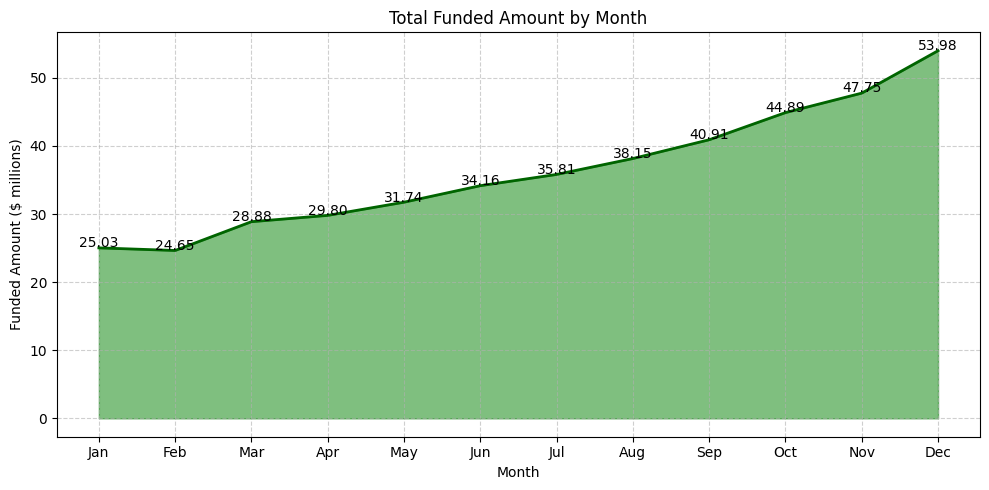

In [20]:
# Sort by date
df = df.sort_values("issue_date")

# Create month name
df["month"] = df["issue_date"].dt.strftime("%b")

# Calculate total funded amount for each month
monthly_funded = df.groupby("month")["loan_amount"].sum()

# Arrange months from January to December
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_funded = monthly_funded.reindex(month_order)

# Convert to millions
monthly_funded = monthly_funded / 1000000

# Create chart
plt.figure(figsize=(10, 5))

plt.fill_between(monthly_funded.index, monthly_funded.values, alpha=0.5, color="green")
plt.plot(monthly_funded.index, monthly_funded.values, linewidth=2, color="darkgreen")

for i, value in enumerate(monthly_funded.values):
    plt.text(i, value + 0.1, f"{value:.2f}", ha="center")

plt.title("Total Funded Amount by Month")
plt.xlabel("Month")
plt.ylabel("Funded Amount ($ millions)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Amount Received

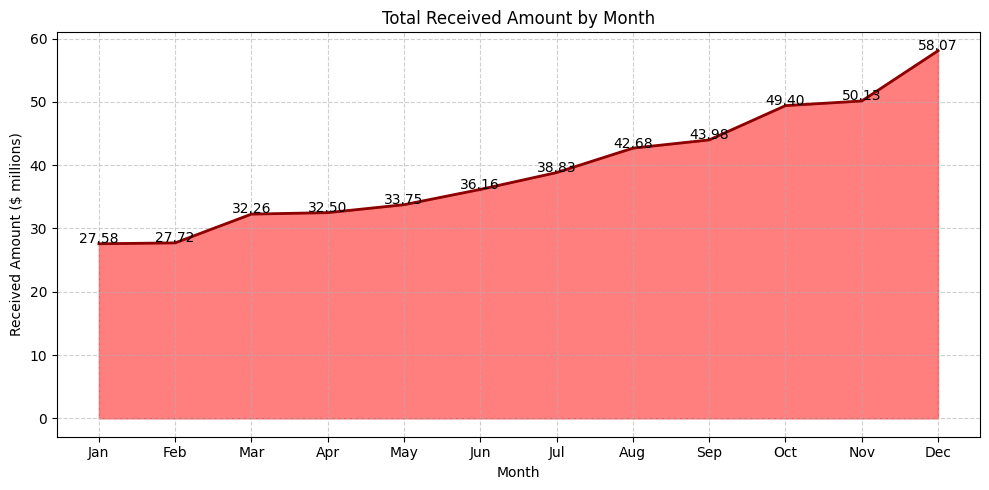

In [21]:
# Sort by date
df = df.sort_values("issue_date")

# Create month name
df["month"] = df["issue_date"].dt.strftime("%b")

# Calculate total received amount for each month
monthly_received = df.groupby("month")["total_payment"].sum()

# Arrange months from January to December
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_received = monthly_received.reindex(month_order)

# Convert to millions
monthly_received = monthly_received / 1000000

# Create chart
plt.figure(figsize=(10, 5))

plt.fill_between(monthly_received.index, monthly_received.values, alpha=0.5, color="red")
plt.plot(monthly_received.index, monthly_received.values, linewidth=2, color="darkred")

for i, value in enumerate(monthly_received.values):
    plt.text(i, value + 0.1, f"{value:.2f}", ha="center")

plt.title("Total Received Amount by Month")
plt.xlabel("Month")
plt.ylabel("Received Amount ($ millions)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Loan Applications

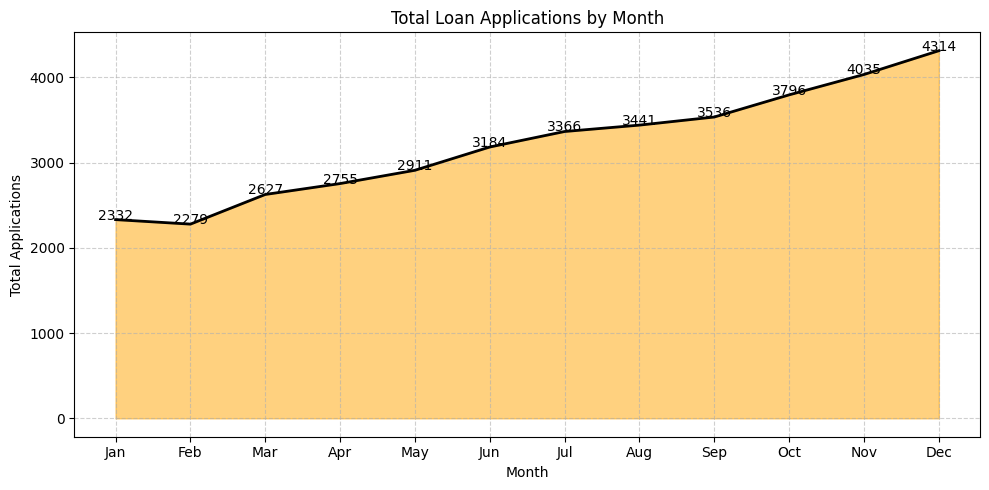

In [22]:
# Sort by date
df = df.sort_values("issue_date")

# Create month name
df["month"] = df["issue_date"].dt.strftime("%b")

# Calculate total applications for each month
total_applications = df.groupby("month")["id"].count()

# Arrange months from January to December
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
total_applications = total_applications.reindex(month_order)

# Create chart
plt.figure(figsize=(10, 5))

plt.fill_between(total_applications.index, total_applications.values, alpha=0.5, color="orange")
plt.plot(total_applications.index, total_applications.values, linewidth=2, color="black")

for i, value in enumerate(total_applications.values):
    plt.text(i, value + 0.1, f"{value:}", ha="center")

plt.title("Total Loan Applications by Month")
plt.xlabel("Month")
plt.ylabel("Total Applications")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

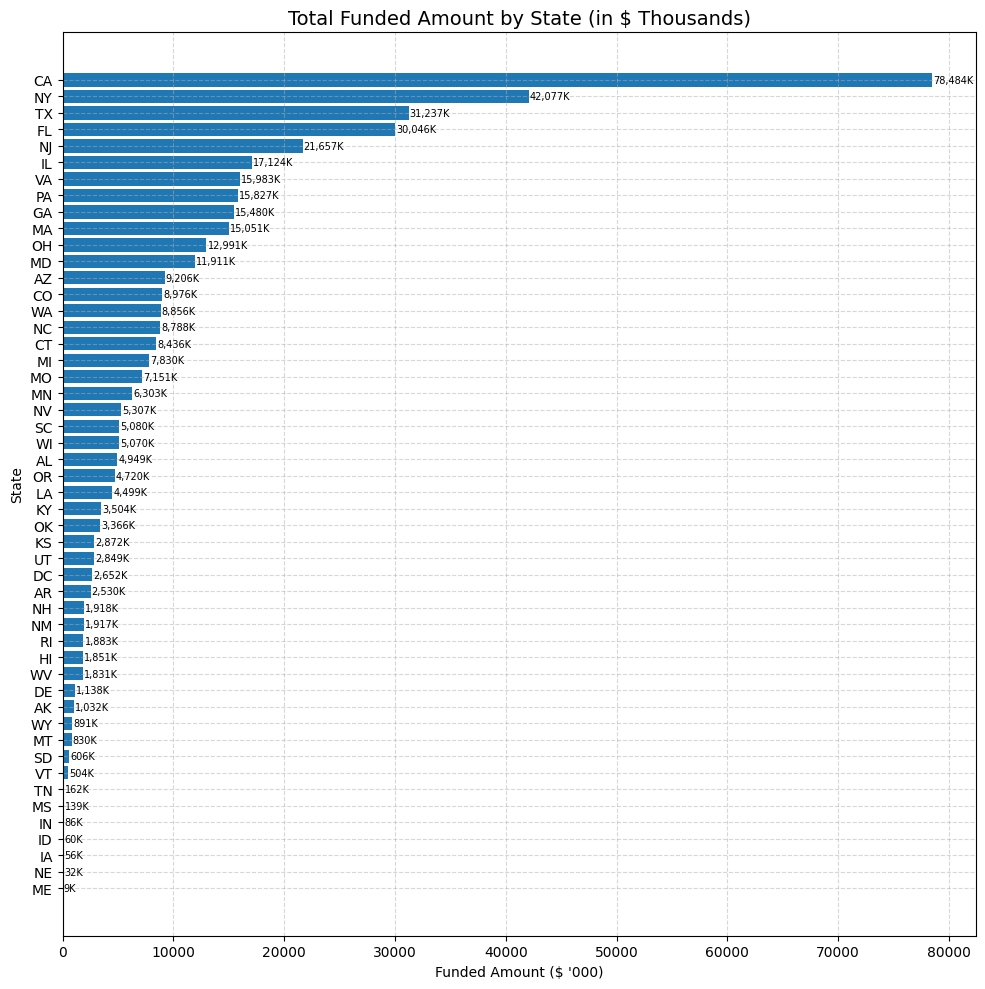

In [23]:
# Calculate total funded amount for each state
state_funded = df.groupby("address_state")["loan_amount"].sum()

# Convert to thousands
state_funded = state_funded / 1000

# Sort from highest to lowest
state_funded = state_funded.sort_values(ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(10, 10))

plt.barh(state_funded.index, state_funded.values)

# Put highest state at the top
plt.gca().invert_yaxis()

for i, value in enumerate(state_funded.values):
    plt.text(value + 100, i, f"{value:,.0f}K", va="center", fontsize=7)

plt.title("Total Funded Amount by State (in $ Thousands)", fontsize=14)
plt.xlabel("Funded Amount ($ '000)")
plt.ylabel("State")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

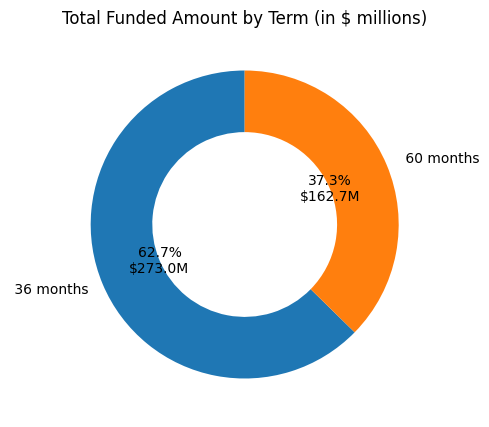

In [24]:
# find total loan amount for each term
term_funding = df.groupby("term")["loan_amount"].sum()

# converting amount into millions
term_funding = term_funding / 1000000

def show_values(percent):
    amount = percent * term_funding.sum() / 100
    return f"{percent:.1f}%\n${amount:.1f}M"

# create donut chart
plt.figure(figsize=(5, 5))

plt.pie(
    term_funding,
    labels=term_funding.index,
    autopct=show_values,
    startangle=90,
    wedgeprops={"width": 0.4}
)
plt.title("Total Funded Amount by Term (in $ millions)")
plt.show()

### Employee Length by Total Funded Amount

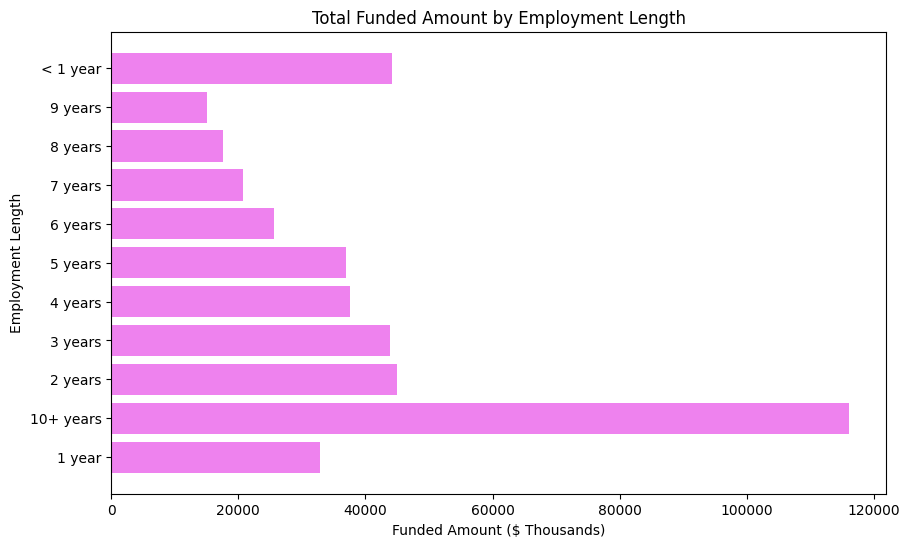

In [25]:
# Total loan amount for each employment length
emp_funding = df.groupby("emp_length")["loan_amount"].sum()

# Convert to thousands
emp_funding = emp_funding / 1000

# Create bar chart
plt.figure(figsize=(10, 6))

plt.barh(emp_funding.index, emp_funding.values, color="violet")

plt.xlabel("Funded Amount ($ Thousands)")
plt.ylabel("Employment Length")
plt.title("Total Funded Amount by Employment Length")

plt.show()

### Loan Purpose by Total Funded Amount

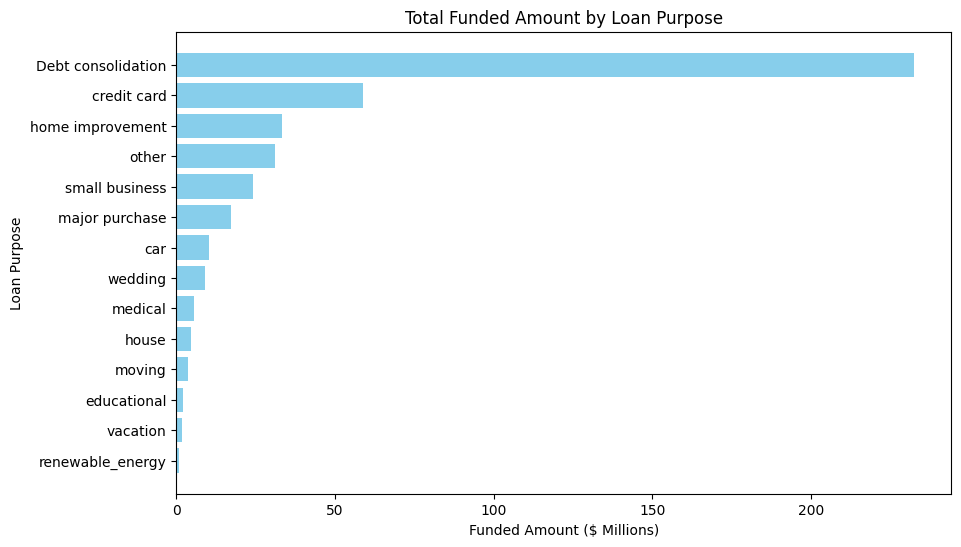

In [26]:
# Total loan amount for each purpose
purpose_funding = df.groupby("purpose")["loan_amount"].sum()

# sort from lowest to highest
purpose_funding = purpose_funding.sort_values()

# Convert to millions
purpose_funding = purpose_funding / 1000000

# Create bar chart
plt.figure(figsize=(10, 6))

plt.barh(purpose_funding.index, purpose_funding.values, color="skyblue")

plt.xlabel("Funded Amount ($ Millions)")
plt.ylabel("Loan Purpose")
plt.title("Total Funded Amount by Loan Purpose")

plt.show()

### Home Ownership Analysis by Total Funded Amount

In [ ]:
home_funding = df.groupby("home_ownership")["loan_amount"].sum().reset_index()

home_funding["loan_amount"] = home_funding["loan_amount"] / 1000000

fig = px.treemap(
    home_funding,
    path=["home_ownership"],
    values="loan_amount",
    color="loan_amount",
    color_continuous_scale="Blues",
    title="Total Funded Amount by Home Ownership ($ Millions)"
)
fig.show()

# Run locally with `pip install plotly` to view the interactive treemap.


### Key Findings

Bringing the risk lens back in — where is default (Charged Off) rate concentrated, rather than just where the volume is?

In [27]:
def charge_off_rate(df, group_col, min_count=50):
    """Charged-off rate (%) per group, restricted to groups with at least
    min_count applications so small samples don\'t distort the ranking."""
    rate = df.groupby(group_col)["loan_status"].apply(lambda s: (s == "Charged Off").mean() * 100)
    count = df.groupby(group_col)["id"].count()
    return rate[count >= min_count].sort_values(ascending=False)

print("Highest default-rate states:")
print(charge_off_rate(df, "address_state").head(5).round(2))

print("\nDefault rate by loan purpose:")
print(charge_off_rate(df, "purpose").head(5).round(2))

print("\nDefault rate by term:")
print(charge_off_rate(df, "term").round(2))

print("\nDefault rate by loan grade:")
print(charge_off_rate(df, "grade").round(2))

Highest default-rate states:
address_state
NV    20.95
AK    19.23
SD    17.46
FL    17.27
HI    16.47
Name: loan_status, dtype: float64

Default rate by loan purpose:
purpose
small business      25.62
renewable_energy    18.09
educational         15.87
house               15.57
other               15.35
Name: loan_status, dtype: float64

Default rate by term:
term
60 months    22.34
36 months    10.71
Name: loan_status, dtype: float64

Default rate by loan grade:
grade
G    31.31
F    30.25
E    24.80
D    20.69
C    16.02
B    11.50
A     5.70
Name: loan_status, dtype: float64


**Summary of findings:**

- **Portfolio health:** 86.18% of loans are Current or Fully Paid; 13.82% are Charged Off, representing $65.53M funded vs. only $37.28M recovered.
- **Term risk:** 60-month loans default at **22.34%**, more than double the rate of 36-month loans (**10.71%**) — term length alone is a strong risk signal.
- **Grade risk:** Default rate rises almost monotonically from Grade A (**5.70%**) to Grade G (**31.31%**), confirming the grading system is doing its job — but the tail grades (E/F/G) carry disproportionate risk.
- **Purpose risk:** `small_business` loans default at **25.62%**, far above the portfolio average, followed by `renewable_energy` (18.09%) and `educational` (15.87%).
- **Geographic concentration:** Nevada (20.95%), Alaska (19.23%), and South Dakota (17.46%) have the highest default rates among states with meaningful volume (50+ loans).

**Recommendation:** Tighten underwriting or pricing for 60-month, small-business-purpose loans in higher-risk states, since these three factors compound rather than being independent risks.